In [1]:
from __future__ import annotations

import copy
import csv
import json
import os
import time
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Tuple
from loguru import logger
import torch
from torch import nn
from data.common import ProblemClass
from torch.optim import Adam
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
# Your codebase imports (run from src/)
from pathlib import Path
from jobs.utils import build_dataloaders, set_all_seeds, device_from_args, pack_by_sizes
from jobs.finetune import eval_epoch
from metrics.optimization import get_optimal_solution, get_optimality_gap, kkt
from models.gnn import GNNPolicy
from models.mlp import KKTNetMLP
import configargparse

In [2]:
out_dir = Path("./results/budget_sweep")
out_dir.mkdir(parents=True, exist_ok=True)
parser = configargparse.ArgumentParser(
    allow_abbrev=False,
    default_config_files=["../configs/finetune/finetune_CA_200/finetune_CA_200_gnn_full_finetune.yml"],
)
parser.add_argument(
        "--encoder_path",
        type=str,
        help="Path to encoder-only checkpoint from pretraining (e.g., .../best_encoder.pt).",
    )
parser.add_argument("--devices", type=str, default="0")
parser.add_argument("--batch_size", type=int, default=8)
parser.add_argument("--num_workers", type=int, default=0)
parser.add_argument("--seed", type=int, default=42)
parser.add_argument(
        "--finetune_mode",
        type=str,
        choices=["full", "heads"],
        default="full",
        help="'full' updates encoder+heads; 'heads' freezes encoder and trains heads only.",
    )

d = parser.add_argument_group("data")

d.add_argument(
    "--use_bipartite_graphs", action="store_true", help="Must be set for GNNPolicy."
)
d.add_argument(
    "--problems",
    type=str,
    nargs="+",
    default=[ProblemClass.COMBINATORIAL_AUCTION],
    help="Problem type(s).",
)
d.add_argument(
    "--is_sizes", type=int, nargs="+", default=[200]
)
d.add_argument(
    "--ca_sizes", type=int, nargs="+", default=[100]
)
d.add_argument(
    "--sc_sizes", type=int, nargs="+", default=[200]
)
d.add_argument(
    "--cfl_sizes", type=int, nargs="+", default=[200]
)
d.add_argument(
    "--rnd_sizes", type=int, nargs="+", default=[200]
)

d.add_argument("--n_instances", type=int, default=35000)
d.add_argument("--data_root", type=str, default="../data/instances")
d.add_argument(
    "--val_split",
    type=float,
    default=0.15,
    help="Validation split ratio (default: 0.15 for 70/15/15 train/val/test)",
)
args, _ = parser.parse_known_args()
GNNPolicy.add_args(parser)
KKTNetMLP.add_args(parser)

args, _ = parser.parse_known_args()

In [3]:
print("Arguments:", args)

Arguments: Namespace(encoder_path='/home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_pretraining_experiments/run_gnn_policy-gv=2-lv=8-slice=512-point=13-lmbd=0.256-std=0.0-dim=128-l_mask=0.6-g_mask=0.05-l_e_mask=0.05-g_e_mask=0.6-dp=0.05-l_dim=128-conv=gatv2-heads=4_20260117_222826/best_encoder.pt', devices='0', batch_size=80, num_workers=0, seed=42, finetune_mode='full', use_bipartite_graphs=True, problems=['CA'], is_sizes=[200], ca_sizes=[100], sc_sizes=[200], cfl_sizes=[200], rnd_sizes=[200], n_instances=50000, data_root='../data/instances', val_split=0.15, lejepa_n_global_views=2, lejepa_n_local_views=8, sigreg_slices=512, sigreg_points=13, lejepa_lambda=0.256, lejepa_std_loss_weight=0.0, embedding_size=128, cons_nfeats=4, edge_nfeats=1, var_nfeats=18, num_emb_type='periodic', num_emb_bins=32, num_emb_freqs=16, lejepa_local_mask=0.6, lejepa_global_mask=0.05, lejepa_local_edge_mask=0.05, lejepa_global_edge_mask=0.6, dropout=0.05, lejepa_embed_dim=128, bipartite_co

In [4]:
set_all_seeds(args.seed)
device = device_from_args(args)

In [5]:
resolved_data_root = os.path.abspath(os.path.expanduser(args.data_root))
print(f"Using data root: {resolved_data_root}")

Using data root: /home/joachim-verschelde/Repos/KKT_MPNN/src/data/instances


In [6]:
def _get_state_dict(pkg):
    if isinstance(pkg, dict):
        if "model" in pkg:
            return pkg["model"]
        if "state_dict" in pkg:
            return pkg["state_dict"]
    return pkg  # assume raw state_dict

def infer_MN_from_ckpt(ckpt_path: Path):
    
    pkg = torch.load(ckpt_path, map_location="cpu")
    sd = _get_state_dict(pkg)

    Din = sd["encoder.trunk.0.weight"].shape[1]

    # adjust keys if your MLP uses different names
    M = sd["head_lam.2.bias"].shape[0]
    N = sd["head_x.2.bias"].shape[0]  # <-- if your x-head is named differently, update this

    expected = M * N + M + N
    if Din != expected:
        raise ValueError(f"Inconsistent dims: Din={Din}, but M*N+M+N={expected} (M={M}, N={N})")
    print(f"M:{M} N:{N}")
    return M, N


In [7]:
experiment_dir = Path("/home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/")
sizes = [10,50,200]
datasets =["ca","all"]
scenarios=["mlp","gnn","gnnff","gnnfe"]
checkpoint_epochs = [1,2,5,10,20,30,50]
out_csv = experiment_dir / "exp1_budget_sweep_results.csv"

# Cache dataloaders per (dataset,size,use_bipartite)
dl_cache: Dict[Tuple[str, int, bool], Tuple] = {}

rows: List[Dict[str, object]] = []

for size in tqdm(sizes):
    size_dir = experiment_dir / Path(str(size))
    for dataset in tqdm(datasets):
        for scenario in tqdm(scenarios):
            model_dir = list(size_dir.glob(f"*-{dataset}-{scenario}"))[0]
            args.problems = [ProblemClass.COMBINATORIAL_AUCTION] if dataset == "ca" else [ProblemClass.CAPACITATED_FACILITY_LOCATION, ProblemClass.SET_COVER, ProblemClass.INDEPENDANT_SET, ProblemClass.COMBINATORIAL_AUCTION]

            args.is_sizes = [size]
            args.ca_sizes = [int(size/2)]
            args.cfl_sizes = [size]
            args.sc_sizes = [size]
            
            args.use_bipartite_graphs = scenario in ["gnn","gnnff","gnnfe"]

            checkpoint_paths = {checkpoint:model_dir / f"epoch_{checkpoint:03d}.pt" for checkpoint in checkpoint_epochs}
            
            cache_key = (dataset, size, args.use_bipartite_graphs)
            
            M_fixed, N_fixed = infer_MN_from_ckpt(checkpoint_paths[1]) if scenario == "mlp" else (None, None)
            
            if cache_key not in dl_cache:
                train_loader, valid_loader, test_loader, N_max, M_max = build_dataloaders(
                    args, M_max=M_fixed, N_max=N_fixed, for_pretraining=False
                )
                dl_cache[cache_key] = (train_loader, valid_loader, test_loader, N_max, M_max)
            else:
                train_loader, valid_loader, test_loader, N_max, M_max = dl_cache[cache_key]
            
            model = (
            GNNPolicy(args).to(device)
                if args.use_bipartite_graphs
                else KKTNetMLP(args, M_fixed, N_fixed).to(device)
            )

            for checkpoint_epoch in tqdm(checkpoint_epochs):
                try:
                    print(f"Loading checkpoint {checkpoint_paths[checkpoint_epoch]}...")
                    args.encoder_path = str(checkpoint_paths[checkpoint_epoch])
                    
                    pkg = torch.load(checkpoint_paths[checkpoint_epoch], map_location="cpu")
                    if isinstance(pkg, dict):
                        if "model" in pkg:
                            model.load_state_dict(pkg["model"], strict=True)
                        elif "state_dict" in pkg:
                            model.load_state_dict(pkg["state_dict"], strict=True)
                    else:
                    # last resort
                        model.load_state_dict(pkg, strict=True)
                    
                    model = model.to(device)         
                    metrics = eval_epoch(model,test_loader, device, 0.1,0.1,0.6,0.2)

                    rows.append({
                                "size": size,
                                "dataset": dataset,
                                "scenario": scenario,
                                "run_dir": model_dir.name,
                                "epoch": checkpoint_epoch,
                                "ckpt_path": str(checkpoint_paths[checkpoint_epoch]),
                                **metrics,
                            })
                except Exception as e:
                    print(f"An exception occured for run: size:{size}, dataset: {dataset}, scenario:{scenario}, checkpoint: {checkpoint_epoch} | {e}")
                    continue



            


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

M:28 N:10
args Namespace(encoder_path='/home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_pretraining_experiments/run_gnn_policy-gv=2-lv=8-slice=512-point=13-lmbd=0.256-std=0.0-dim=128-l_mask=0.6-g_mask=0.05-l_e_mask=0.05-g_e_mask=0.6-dp=0.05-l_dim=128-conv=gatv2-heads=4_20260117_222826/best_encoder.pt', devices='0', batch_size=80, num_workers=0, seed=42, finetune_mode='full', use_bipartite_graphs=False, problems=['CA'], is_sizes=[10], ca_sizes=[5], sc_sizes=[10], cfl_sizes=[10], rnd_sizes=[200], n_instances=50000, data_root='../data/instances', val_split=0.15, lejepa_n_global_views=2, lejepa_n_local_views=8, sigreg_slices=512, sigreg_points=13, lejepa_lambda=0.256, lejepa_std_loss_weight=0.0, embedding_size=128, cons_nfeats=4, edge_nfeats=1, var_nfeats=18, num_emb_type='periodic', num_emb_bins=32, num_emb_freqs=16, lejepa_local_mask=0.6, lejepa_global_mask=0.05, lejepa_local_edge_mask=0.05, lejepa_global_edge_mask=0.6, dropout=0.05, lejepa_embed_dim=128, bipartite_co

  0%|          | 0/7 [00:00<?, ?it/s]

...

Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/53-swift-darkness-all-gnn/epoch_001.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/53-swift-darkness-all-gnn/epoch_002.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/53-swift-darkness-all-gnn/epoch_005.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/53-swift-darkness-all-gnn/epoch_010.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/53-swift-darkness-all-gnn/epoch_020.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/53-swift-darkness-all-gnn/epoch_030.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN

  0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/56-blooming-wind-all-gnnff/epoch_001.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/56-blooming-wind-all-gnnff/epoch_002.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/56-blooming-wind-all-gnnff/epoch_005.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/56-blooming-wind-all-gnnff/epoch_010.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/56-blooming-wind-all-gnnff/epoch_020.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/56-blooming-wind-all-gnnff/epoch_030.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KK

  0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/69-breezy-sky-all-gnnfe/epoch_001.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/69-breezy-sky-all-gnnfe/epoch_002.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/69-breezy-sky-all-gnnfe/epoch_005.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/69-breezy-sky-all-gnnfe/epoch_010.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/69-breezy-sky-all-gnnfe/epoch_020.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experiments/kkt_gnn_node_finetuning_experiments/200/69-breezy-sky-all-gnnfe/epoch_030.pt...
Loading checkpoint /home/joachim-verschelde/Repos/KKT_MPNN/src/experim

In [8]:
import pandas as pd
rows_df = pd.DataFrame(rows)

In [10]:
rows_df.head()

,size,dataset,scenario,run_dir,epoch,ckpt_path,valid/kkt_loss,valid/primal_feasibility,valid/dual_feasibility,valid/stationarity,valid/complementary_slackness,valid/optimality_gap,valid/objective_gap
0,10,ca,mlp,42-restful-resonance-ca-mlp,1,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,2099.317174,0.000838,0.0,2080.679645,18.636709,0.127671,0.147425
1,10,ca,mlp,42-restful-resonance-ca-mlp,2,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,1942.740559,0.002556,0.0,1912.423045,30.314966,0.102592,0.076659
2,10,ca,mlp,42-restful-resonance-ca-mlp,5,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,1665.954309,0.000674,0.0,1634.177206,31.776422,0.356215,0.195196
3,10,ca,mlp,42-restful-resonance-ca-mlp,10,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,551.391272,0.006625,0.0,486.180273,65.204367,0.290920,0.023376
4,10,ca,mlp,42-restful-resonance-ca-mlp,20,/home/joachim-verschelde/Repos/KKT_MPNN/src/ex...,335.552522,0.005062,0.0,283.348594,52.198863,0.274950,0.045373


In [11]:
rows_ca_df = rows_df[rows_df.dataset=='ca']

In [13]:
rows_ca_df.columns

Index(['size', 'dataset', 'scenario', 'run_dir', 'epoch', 'ckpt_path',
       'valid/kkt_loss', 'valid/primal_feasibility', 'valid/dual_feasibility',
       'valid/stationarity', 'valid/complementary_slackness',
       'valid/optimality_gap', 'valid/objective_gap'],
      dtype='object')

In [16]:
import numpy as np
import pandas as pd

# Epoch budgets used in the paper tables
EPOCHS = [1, 2, 5, 10, 20, 30, 50]

# Row order used in the LaTeX tables
METHOD_ORDER = ["MLP-BL", "GNN-BL", "GNN-FE", "GNN-FF"]

# --- IMPORTANT ---
# Map your df["scenario"] values to the paper method names.
# Adjust this mapping to match your actual scenario strings.
#
# Tip: run `df["scenario"].unique()` once to see what you should map from.
SCENARIO_TO_METHOD = {
    "mlp": "MLP-BL",
    "gnn": "GNN-BL",
    "gnnfe": "GNN-FE",
    "gnnff": "GNN-FF",
    # If your scenarios include extra suffixes/prefixes, add them here, e.g.:
    # "mlp_bl_kkt": "MLP-BL",
    # "gnn_bl_kkt": "GNN-BL",
}

def budget_sweep_pivot(
    df: pd.DataFrame,
    size: int,
    *,
    dataset: str | None = None,
    metric: str = "valid/optimality_gap",
    multiply_by_100: bool = True,
    agg_across_runs: str = "mean",  # "mean" or "median"
) -> pd.DataFrame:
    """
    Returns a (Method x Epoch) pivot table for a given problem size.
    Aggregation:
      1) collapse duplicates within a run (same run_dir/epoch) by mean
      2) aggregate across runs by agg_across_runs
    """
    d = df.copy()

    # filter
    d = d[d["epoch"].isin(EPOCHS)]
    d = d[d["size"] == size]
    if dataset is not None:
        d = d[d["dataset"] == dataset]

    # map scenario -> Method (fallback: keep scenario text if unmapped)
    d["Method"] = d["scenario"].map(SCENARIO_TO_METHOD).fillna(d["scenario"])

    # make sure metric exists
    if metric not in d.columns:
        raise KeyError(f"Metric column '{metric}' not found. Available columns: {list(d.columns)}")

    # 1) de-duplicate within run/epoch (if needed)
    d1 = (
        d.groupby(["size", "dataset", "Method", "run_dir", "epoch"], as_index=False)[metric]
         .mean()
    )

    # 2) aggregate across runs
    if agg_across_runs == "mean":
        d2 = d1.groupby(["size", "dataset", "Method", "epoch"], as_index=False)[metric].mean()
    elif agg_across_runs == "median":
        d2 = d1.groupby(["size", "dataset", "Method", "epoch"], as_index=False)[metric].median()
    else:
        raise ValueError("agg_across_runs must be 'mean' or 'median'")

    if multiply_by_100:
        d2[metric] = 100.0 * d2[metric]

    # pivot to Method x Epoch
    pivot = d2.pivot_table(index="Method", columns="epoch", values=metric, aggfunc="first")

    # enforce paper ordering and columns
    pivot = pivot.reindex(METHOD_ORDER)
    pivot = pivot.reindex(columns=EPOCHS)

    return pivot


def pivot_to_latex_table(
    pivot: pd.DataFrame,
    *,
    caption: str,
    label: str,
    floatfmt: str = "{:.2f}",
    missing_cell: str = r"\textit{[ ]}",
) -> str:
    """Render a pivot (Method x Epoch) into the LaTeX table format you showed."""
    header = ["Method", r"$E{=}1$", "2", "5", "10", "20", "30", "50"]

    lines = []
    lines.append(r"\begin{table}[H]")
    lines.append(fr"\caption{{{caption}}}")
    lines.append(fr"\label{{{label}}}")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\begin{tabular}{l" + "c"*len(EPOCHS) + "}")
    lines.append(r"\hline")
    lines.append(" & ".join(header) + r" \\")
    lines.append(r"\hline")

    for method in METHOD_ORDER:
        row = [method]
        for e in EPOCHS:
            x = np.nan
            if method in pivot.index and e in pivot.columns:
                x = pivot.loc[method, e]
            if pd.isna(x):
                row.append(missing_cell)
            else:
                row.append(floatfmt.format(float(x)))
        lines.append(" & ".join(row) + r" \\")
    lines.append(r"\hline")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    return "\n".join(lines)


# -------------------------
# USAGE
# -------------------------

# If you have multiple datasets in df, set this to the one you want (e.g. "combinatorial_auction").
# Otherwise leave as None.
DATASET_FILTER = None  # e.g. "combinatorial_auction"

# Build the three pivots
t10  = budget_sweep_pivot(rows_ca_df, 10,  dataset=DATASET_FILTER)
t50  = budget_sweep_pivot(rows_ca_df, 50,  dataset=DATASET_FILTER)
t200 = budget_sweep_pivot(rows_ca_df, 200, dataset=DATASET_FILTER)

# (Optional) Inspect as pandas tables
display(t10)
display(t50)
display(t200)

# Emit LaTeX matching your paper tables
latex10 = pivot_to_latex_table(
    t10,
    caption=r"Validation relative optimality gap (\%) after $E$ fine-tuning epochs on the KKT loss for $n=10$. Lower is better.",
    label="tab:budget_sweep_n10",
)
latex50 = pivot_to_latex_table(
    t50,
    caption=r"Validation relative optimality gap (\%) after $E$ fine-tuning epochs for $n=50$.",
    label="tab:budget_sweep_n50",
)
latex200 = pivot_to_latex_table(
    t200,
    caption=r"Validation relative optimality gap (\%) after $E$ fine-tuning epochs for $n=200$.",
    label="tab:budget_sweep_n200",
)

print(latex10)
print()
print(latex50)
print()
print(latex200)


epoch,1,2,5,10,20,30,50
Method,,,,,,,
MLP-BL,12.767089,10.259219,35.621548,29.091996,27.495050,28.751084,22.444667
GNN-BL,22.213107,20.141867,18.149253,17.317465,18.249620,16.823552,16.895770
GNN-FE,23.974442,20.265249,19.551112,19.171273,18.994086,18.943073,18.957603
GNN-FF,19.600466,19.532942,17.927130,17.479951,17.126825,16.682792,17.017141


epoch,1,2,5,10,20,30,50
Method,,,,,,,
MLP-BL,36.224624,10.223470,31.175064,17.421675,12.395297,13.069767,11.078256
GNN-BL,31.301847,32.011245,20.815316,21.999100,11.688571,9.092406,9.295506
GNN-FE,33.455157,15.016186,24.804594,20.791594,17.253385,15.907789,18.561988
GNN-FF,15.480885,11.890531,11.197881,21.323832,11.331414,9.632234,9.920930


epoch,1,2,5,10,20,30,50
Method,,,,,,,
MLP-BL,45.035689,19.073862,15.474581,21.697327,19.778297,23.365139,21.626365
GNN-BL,19.118880,19.270851,25.909628,18.008449,17.357220,7.729141,7.078812
GNN-FE,21.680687,25.315192,20.603274,26.253444,19.702890,24.128702,22.434302
GNN-FF,19.260590,19.411158,11.804763,11.755717,14.090876,18.157320,16.947538


\begin{table}[H]
\caption{Validation relative optimality gap (\%) after $E$ fine-tuning epochs on the KKT loss for $n=10$. Lower is better.}
\label{tab:budget_sweep_n10}
\centering
\small
\begin{tabular}{lccccccc}
\hline
Method & $E{=}1$ & 2 & 5 & 10 & 20 & 30 & 50 \\
\hline
MLP-BL & 12.77 & 10.26 & 35.62 & 29.09 & 27.50 & 28.75 & 22.44 \\
GNN-BL & 22.21 & 20.14 & 18.15 & 17.32 & 18.25 & 16.82 & 16.90 \\
GNN-FE & 23.97 & 20.27 & 19.55 & 19.17 & 18.99 & 18.94 & 18.96 \\
GNN-FF & 19.60 & 19.53 & 17.93 & 17.48 & 17.13 & 16.68 & 17.02 \\
\hline
\end{tabular}
\end{table}

\begin{table}[H]
\caption{Validation relative optimality gap (\%) after $E$ fine-tuning epochs for $n=50$.}
\label{tab:budget_sweep_n50}
\centering
\small
\begin{tabular}{lccccccc}
\hline
Method & $E{=}1$ & 2 & 5 & 10 & 20 & 30 & 50 \\
\hline
MLP-BL & 36.22 & 10.22 & 31.18 & 17.42 & 12.40 & 13.07 & 11.08 \\
GNN-BL & 31.30 & 32.01 & 20.82 & 22.00 & 11.69 & 9.09 & 9.30 \\
GNN-FE & 33.46 & 15.02 & 24.80 & 20.79 & 17.25 & 15.9

  Method                 run_dir  epoch  valid/optimality_gap
0    gnn  48-glowing-surf-ca-gnn      1             22.213107
1    gnn  48-glowing-surf-ca-gnn      2             20.141867
2    gnn  48-glowing-surf-ca-gnn      5             18.149253
3    gnn  48-glowing-surf-ca-gnn     10             17.317465
4    gnn  48-glowing-surf-ca-gnn     20             18.249620
  Method  epoch       mean  std  n_runs
0    gnn      1  22.213107  NaN       1
1    gnn      2  20.141867  NaN       1
2    gnn      5  18.149253  NaN       1
3    gnn     10  17.317465  NaN       1
4    gnn     20  18.249620  NaN       1
  Method  epoch       mean  std  n_runs
0    gnn      1  22.213107  NaN       1
1    gnn      2  20.141867  NaN       1
2    gnn      5  18.149253  NaN       1
3    gnn     10  17.317465  NaN       1
4    gnn     20  18.249620  NaN       1
  Method                run_dir  epoch  valid/optimality_gap
0    gnn  49-balmy-dream-ca-gnn      1             31.301847
1    gnn  49-balmy-dream-c

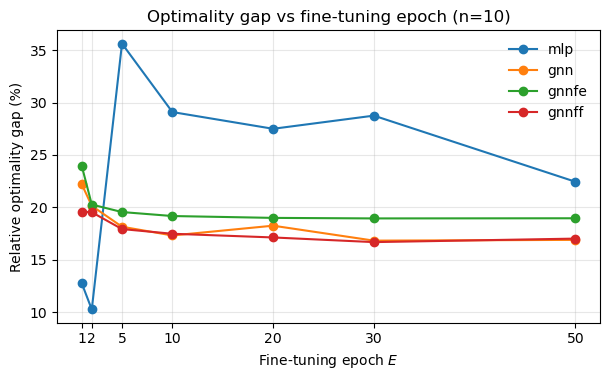

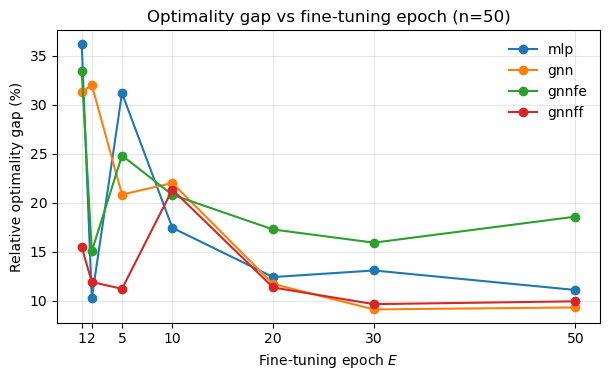

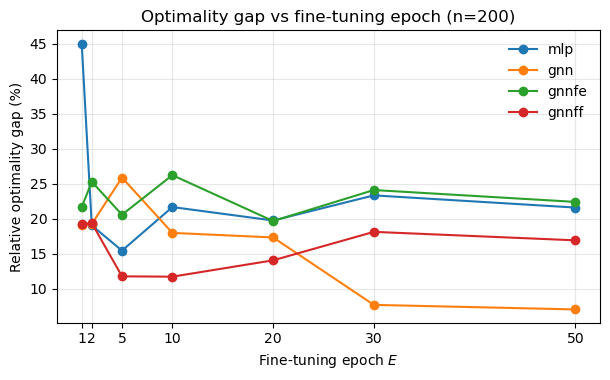

In [31]:
from matplotlib import pyplot as plt

def _scale_for_percent(values: pd.Series, df_gap_unit: str):
    """
    Returns (scale_factor, y_label).
    df_gap_unit:
      - "auto": if 95th percentile <= 1.0 assume fraction -> multiply by 100
      - "fraction": assume values in [0,1] -> multiply by 100
      - "percent": assume already in % units -> multiply by 1
    """
    v = values.dropna()
    if v.empty:
        return 1.0, "Relative optimality gap (%)"

    if df_gap_unit == "fraction":
        return 100.0, "Relative optimality gap (%)"
    if df_gap_unit == "percent":
        return 1.0, "Relative optimality gap (%)"
    if df_gap_unit == "auto":
        q95 = v.quantile(0.95)
        # Heuristic: if values mostly <= 1, it's probably a fraction
        return (100.0, "Relative optimality gap (%)") if q95 <= 1.0 else (1.0, "Relative optimality gap (%)")

    raise ValueError("df_gap_unit must be one of: 'auto', 'fraction', 'percent'")


def summarize_gap_over_runs(
    df: pd.DataFrame,
    size: int,
    *,
    dataset: str | None = None,
    metric: str = "valid/optimality_gap",
    epoch_subset: list[int] | None = EPOCHS,
    df_gap_unit: str = "auto",
) -> tuple[pd.DataFrame, str]:
    """
    Produces a tidy summary with columns:
      Method, epoch, mean, std, n_runs
    Aggregation:
      1) collapse duplicates within a run_dir at same epoch by mean
      2) aggregate across run_dir by mean + std
    """
    d = df.copy()

    d = d[d["size"] == size]
    if dataset is not None:
        d = d[d["dataset"] == dataset]

    if epoch_subset is not None:
        d = d[d["epoch"].isin(epoch_subset)]

    if metric not in d.columns:
        raise KeyError(f"'{metric}' not in df.columns")
    # scenario -> Method
    d["Method"] = d["scenario"].map(SCENARIO_TO_METHOD).fillna(d["scenario"])

    # Determine scaling for percent display
    scale, y_label = _scale_for_percent(d[metric], df_gap_unit=df_gap_unit)

    # 1) de-dup within run_dir/epoch (in case you logged multiple times)
    per_run = (
        d.groupby(["Method", "run_dir", "epoch"], as_index=False)[metric]
         .mean()
    )
    per_run[metric] = per_run[metric] * scale

    print(per_run.head())
    # 2) across runs
    summary = (
        per_run.groupby(["Method", "epoch"], as_index=False)[metric]
               .agg(mean="mean", std="std", n_runs="count")
    )
    print(summary.head())
    # Enforce order + epochs
    summary["Method"] = pd.Categorical(summary["Method"], categories=["mlp", "gnn", "gnnfe", "gnnff"], ordered=True)
    print(summary.head())
    summary = summary.sort_values(["Method", "epoch"])
    

    return summary, y_label


def plot_gap_vs_epoch(
    df: pd.DataFrame,
    size: int,
    *,
    dataset: str | None = None,
    metric: str = "valid/optimality_gap",
    epoch_subset: list[int] | None = EPOCHS,   # set None to plot ALL epochs present
    df_gap_unit: str = "auto",                 # "auto" | "fraction" | "percent"
    show_band: bool = True,                    # mean ± std band
    savepath: str | None = None,
):
    summary, y_label = summarize_gap_over_runs(
        df,
        size,
        dataset=dataset,
        metric=metric,
        epoch_subset=epoch_subset,
        df_gap_unit=df_gap_unit,
    )

    fig, ax = plt.subplots(figsize=(6.2, 3.9))

    for method in ["mlp", "gnn", "gnnfe", "gnnff"]:
        s = summary[summary["Method"] == method]
        if s.empty:
            continue

        # Line first (default matplotlib colors)
        (line,) = ax.plot(s["epoch"], s["mean"], marker="o", label=method)

        # Shaded band: mean ± std (if std exists)
        if show_band and "std" in s.columns:
            lo = (s["mean"] - s["std"]).to_numpy()
            hi = (s["mean"] + s["std"]).to_numpy()
            x = s["epoch"].to_numpy()
            ax.fill_between(x, lo, hi, alpha=0.2, color=line.get_color())

    ax.set_title(f"Optimality gap vs fine-tuning epoch (n={size})")
    ax.set_xlabel("Fine-tuning epoch $E$")
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)

    # Nice x-ticks if you’re using the sweep budgets
    if epoch_subset is not None:
        ax.set_xticks(epoch_subset)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")

    return fig, ax


# -----------------------
# MAKE THE 3 PLOTS
# -----------------------

DATASET_FILTER = None  # e.g. "combinatorial_auction" if you want to filter

for n in [10, 50, 200]:
    plot_gap_vs_epoch(
        rows_ca_df,
        n,
        dataset=DATASET_FILTER,
        metric="valid/optimality_gap",
        epoch_subset=EPOCHS,     # or None for all epochs
        df_gap_unit="auto",      # or force "fraction" / "percent"
        show_band=True,
        savepath=f"opt_gap_vs_epoch_n{n}.pdf",  # comment out if you don't want files
    )

plt.show()